# MongoDB: Installation, Database Import, and Queries

In the following two lectures, we will perform several queries with MongoDB on the [Instacart database](https://www.instacart.com/company). We will see how to:

1.  Import the MongoDB database
2.  Install the PyMongo Python library to communicate with the MongoDB server
3.  Perform synchronous queries with PyMongo on the Instacart database
4.  Perform asynchronous queries with Motor on the Instacart database

Instacart - An anonymized online grocery shopping database.
Each document in orders is one Instacart order: it stores which user made the order, when they ordered (day of week, hour), and a list of the products they bought in that order.
The dataset is meant for analyzing shopping behavior, for example: when people shop, which products are bought together, and how often users reorder the same items.


---

## 1. Import Database

Now, let's import the MongoDB version of the *Instacart* database. We can import the database with the following command. The `--drop` flag ensures a clean import by removing any existing collections with the same name first.

```cmd
mongorestore.exe ^
  --host localhost ^
  --port 27017 ^
  --db instacart ^
  --archive="C:\mongo-backup\instacart_dump.gz" ^
  --gzip ^
  --drop
```

> We have named the database `instacart` and the primary collection `orders`.

> **Note for Windows Users**
>
> By default, you have to use the full path to the `mongorestore.exe` executable. Alternatively, you can add its directory to your system's PATH variable to run it from anywhere.
>
> For example, if the full path to the tools is `C:\mongodb-database-tools-windows-x86_64-100.13.0\bin\`, you would run the command like this:
>
> ```cmd
> "C:\mongodb-database-tools-windows-x86_64-100.13.0\bin\mongorestore.exe" ^
>   --host localhost ^
>   --port 27017 ^
>   --db instacart ^
>   --archive="C:\mongo-backup\instacart_dump.gz" ^
>   --gzip ^
>   --drop
> ```
>
> *Notice that values in the Windows PATH variable have to end with `\` or `/`.*

---

## 2. PyMongo

As with PostgreSQL, we need a library that provides an interface with MongoDB. This is **PyMongo**: it is a Python library containing tools to work with MongoDB and is the recommended way to work with MongoDB from Python.

We can install PyMongo with pip (`pip install pymongo`) or Anaconda. The official documentation for the library can be found here: <https://www.mongodb.com/docs/languages/python/pymongo-driver/current/>

In [ ]:
#!pip install pymongo

In [1]:
import pymongo

In [2]:
client = pymongo.MongoClient() # host has to be specified if not "localhost"
#client = pymongo.MongoClient("mongodb://172.20.27.85:27017/")
client

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True)

In [3]:
# Show dbs
client.list_database_names()

['FaithInterFolia', 'admin', 'config', 'instacart', 'local']

In [4]:
# Use instacart
db = client['instacart']
type(db)

pymongo.synchronous.database.Database

In [5]:
# Show collections
db.list_collection_names()

['orders']

In [6]:
# Use orders
cll = db['orders'] # collection
type(cll)

pymongo.synchronous.collection.Collection

Using ```find_one()``` we get one document that satisfies the specified query criteria on the collection. Notice here that the query argument is empty.

If multiple documents satisfy the query, this method returns the first document according to the order of documents on the disk.

In [7]:
# How is an object of the database made?
example = cll.find_one()
example

{'_id': ObjectId('60af57782fbbe971834ae2a6'),
 'order_id': 2539329,
 'user_id': 1,
 'order_number': 1,
 'order_dow': 2,
 'order_hour_of_day': 8,
 'products': [{'product_id': 196,
   'product_name': 'Soda',
   'aisle_id': 77,
   'aisle': 'soft drinks',
   'department_id': 7,
   'department': 'beverages',
   'add_to_cart_order': 1},
  {'product_id': 12427,
   'product_name': 'Original Beef Jerky',
   'aisle_id': 23,
   'aisle': 'popcorn jerky',
   'department_id': 19,
   'department': 'snacks',
   'add_to_cart_order': 3},
  {'product_id': 14084,
   'product_name': 'Organic Unsweetened Vanilla Almond Milk',
   'aisle_id': 91,
   'aisle': 'soy lactosefree',
   'department_id': 16,
   'department': 'dairy eggs',
   'add_to_cart_order': 2},
  {'product_id': 26088,
   'product_name': 'Aged White Cheddar Popcorn',
   'aisle_id': 23,
   'aisle': 'popcorn jerky',
   'department_id': 19,
   'department': 'snacks',
   'add_to_cart_order': 4},
  {'product_id': 26405,
   'product_name': 'XL Pick-A-S

Every document in the collection has an <i>_id</i> field that is used to uniquely identify the document in a particular collection. It acts as the primary key for the documents in the collection.

Using ```find()``` we get all documents that satisfies the specified query criteria on the collection. The result is a cursor. We have to iterate over the cursor in order to access data.

In [8]:
cursor = cll.find()

In [27]:
record = next(cursor)
record

{'_id': ObjectId('60af57782fbbe971834ae2b8'),
 'order_id': 788338,
 'user_id': 2,
 'order_number': 8,
 'order_dow': 1,
 'order_hour_of_day': 15,
 'days_since_prior_order': 27,
 'products': [{'product_id': 23,
   'product_name': 'Organic Turkey Burgers',
   'aisle_id': 49,
   'aisle': 'packaged poultry',
   'department_id': 12,
   'department': 'meat seafood',
   'add_to_cart_order': 12},
  {'product_id': 2002,
   'product_name': 'The \\"World\'s Best\\" Veggie Burger',
   'aisle_id': 42,
   'aisle': 'frozen vegan vegetarian',
   'department_id': 1,
   'department': 'frozen',
   'add_to_cart_order': 14},
  {'product_id': 5212,
   'product_name': 'Watermelon Chunks',
   'aisle_id': 123,
   'aisle': 'packaged vegetables fruits',
   'department_id': 4,
   'department': 'produce',
   'add_to_cart_order': 15},
  {'product_id': 14306,
   'product_name': 'Organic Packham Or Anjou Pears',
   'aisle_id': 110,
   'aisle': 'pickled goods olives',
   'department_id': 13,
   'department': 'pantry',


Add/remove/update

In [28]:
# update_one, update_many
query = {"user_id":1}

# $set will add the field if it doesn't exist, or update it if it does.
add_operation = {"$set": {"name": "John Smith"}}

# Execute the update for a single document
cll.update_many(query, add_operation)

UpdateResult({'n': 11, 'nModified': 11, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [29]:
update_operation = {"$set": {"name": "John Smith Junior"}}

# Execute the update for MANY documents
cll.update_many(query, update_operation)

UpdateResult({'n': 11, 'nModified': 11, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [30]:

from bson import ObjectId

query = {"_id": ObjectId("60af57782fbbe971834ae2a6")}
update_operation = {"$set": {"name": "John"}}

cll.update_one(query, update_operation)


UpdateResult({'n': 1, 'nModified': 1, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [31]:
# $unset
query = {"user_id":1}
remove_operation = {"$unset": {"name": ""}}

# Execute the update
cll.update_many(query, remove_operation)

UpdateResult({'n': 11, 'nModified': 11, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

## Simple queries

#### Display all the orders of the user with id equal to 1

In [35]:
query = {"user_id" : 1}

cursor = cll.find(query)

In [36]:
print("User ID\t Order ID")
for obj in cursor:
    print(obj['user_id'], " \t", obj['order_id'])

User ID	 Order ID
1  	 2539329
1  	 2398795
1  	 473747
1  	 2254736
1  	 431534
1  	 3367565
1  	 550135
1  	 3108588
1  	 2295261
1  	 2550362
1  	 1187899


In [34]:
# Notice cursor objects get "exhausted", just like in the case we saw with PsycoPG
print("User ID\t Order ID")
for obj in cursor:
    print(obj['user_id'],"\t", obj['order_id'])

User ID	 Order ID


# 3. Perform queries using PyMongo
There are two fundamental operations in a MongoDB query:
1. filter (~ ``WHERE`` in SQL)
2. projection (~ ``SELECT`` in SQL)

In [37]:
query = {"user_id" : 1}
projection = {'_id' : 0, 'user_id' : 0, 'products' : 0} # Exclusive projection

cursor = cll.find(filter = query, projection = projection)

for record in cursor:
    print(record)

{'order_id': 2539329, 'order_number': 1, 'order_dow': 2, 'order_hour_of_day': 8}
{'order_id': 2398795, 'order_number': 2, 'order_dow': 3, 'order_hour_of_day': 7, 'days_since_prior_order': 15}
{'order_id': 473747, 'order_number': 3, 'order_dow': 3, 'order_hour_of_day': 12, 'days_since_prior_order': 21}
{'order_id': 2254736, 'order_number': 4, 'order_dow': 4, 'order_hour_of_day': 7, 'days_since_prior_order': 29}
{'order_id': 431534, 'order_number': 5, 'order_dow': 4, 'order_hour_of_day': 15, 'days_since_prior_order': 28}
{'order_id': 3367565, 'order_number': 6, 'order_dow': 2, 'order_hour_of_day': 7, 'days_since_prior_order': 19}
{'order_id': 550135, 'order_number': 7, 'order_dow': 1, 'order_hour_of_day': 9, 'days_since_prior_order': 20}
{'order_id': 3108588, 'order_number': 8, 'order_dow': 1, 'order_hour_of_day': 14, 'days_since_prior_order': 14}
{'order_id': 2295261, 'order_number': 9, 'order_dow': 1, 'order_hour_of_day': 16}
{'order_id': 2550362, 'order_number': 10, 'order_dow': 4, 'o

In [39]:
query = {"user_id" : 1}
projection = {'order_id' : 1, '_id':0} # Inclusive projection

cursor = cll.find(query, projection)

for record in cursor :
    print(record)

{'order_id': 2539329}
{'order_id': 2398795}
{'order_id': 473747}
{'order_id': 2254736}
{'order_id': 431534}
{'order_id': 3367565}
{'order_id': 550135}
{'order_id': 3108588}
{'order_id': 2295261}
{'order_id': 2550362}
{'order_id': 1187899}


To impose conditions on nested features:

In [40]:
query = {'user_id': 1, "products.add_to_cart_order": 7}
projection = {'products.add_to_cart_order':1, "_id":0}
cursor = cll.find(query, projection)

for record in cursor:
    print(record)

{'products': [{'add_to_cart_order': 1}, {'add_to_cart_order': 3}, {'add_to_cart_order': 5}, {'add_to_cart_order': 2}, {'add_to_cart_order': 8}, {'add_to_cart_order': 6}, {'add_to_cart_order': 4}, {'add_to_cart_order': 7}]}
{'products': [{'add_to_cart_order': 1}, {'add_to_cart_order': 6}, {'add_to_cart_order': 9}, {'add_to_cart_order': 8}, {'add_to_cart_order': 5}, {'add_to_cart_order': 7}, {'add_to_cart_order': 4}, {'add_to_cart_order': 3}, {'add_to_cart_order': 2}]}
{'products': [{'add_to_cart_order': 1}, {'add_to_cart_order': 6}, {'add_to_cart_order': 7}, {'add_to_cart_order': 2}, {'add_to_cart_order': 8}, {'add_to_cart_order': 4}, {'add_to_cart_order': 9}, {'add_to_cart_order': 3}, {'add_to_cart_order': 5}, {'add_to_cart_order': 11}, {'add_to_cart_order': 10}]}


### Exception handling

In [41]:
# Note: By default MongoDB databases are not secured by authentication
import pandas as pd

def query(database, collection, query=None, projection=None, host='localhost', port=27017, limit=0):
    try:
        client = pymongo.MongoClient(host=host, port=port)
        db = client[database]
        cll = db[collection]
    except (ConnectionError) as e:
        print(e)
    
    else:
        try:
            cursor = cll.find(query, projection).limit(limit)
            return pd.DataFrame.from_records(list(cursor))
        except (Exception) as e:
            print(e)
        finally:
            client.close()            

query('instacart', 'orders', query={"user_id" : 1}, projection={"products":0, "_id":0})

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0
5,3367565,1,6,2,7,19.0
6,550135,1,7,1,9,20.0
7,3108588,1,8,1,14,14.0
8,2295261,1,9,1,16,NaN
9,2550362,1,10,4,8,30.0


### Exercise 1.1 
##### How many orders were set on Tuesday at 12:00?

The ``count_documents`` method is available to perform counts (documentation [here](https://pymongo.readthedocs.io/en/stable/api/pymongo/collection.html#pymongo.collection.Collection.count_documents)). It receives a filter and it counts the number of documents that are compliant to the filter.

In [42]:
query = {"order_dow" : 2, "order_hour_of_day" : 12}
cll.count_documents(query)

10384

Method ```count_documents()``` is equivalent to ```find()``` plus transforming the cursor object into a list and computing its length.

In [43]:
len(list(cll.find(query)))

10384

In [44]:
from timeit import timeit

In [45]:
timeit("""cll.count_documents(query)""", number = 10, globals = {'cll':cll, 'query':query})

5.696219700002985

In [46]:
timeit("""len(list(cll.find(query)))""", number = 10, globals = {'cll':cll, 'query':query})

9.527018799999496

### Aggregation

In order to perform more complex queries the filter-projection mechanism is not enough, so we have to use aggregation. As you may have seen in general MongoDB theory, aggregation is a way to specify a pipeline of operations to be performed on a collection. The `match` operator here substitutes the filter operation, and the `project` operator works in the same way as the projection in previous queries. Furthermore, we can have `group`, `unwind`, `sort` and many other operators.

In [47]:
cursor = cll.aggregate([
    {'$match': query}, 
    {'$group': {'_id': None, 
                'count': {'$sum': 1}}}
])

cursor.next() 

{'_id': None, 'count': 10384}

In [48]:
# More or less as fast as the count_documents function
timeit("""cll.aggregate([{'$match': query}, {'$group': {'_id': None, 'count': {'$sum':1}}}])""", number = 10, globals = {'cll':cll, 'query':query})

5.670944799996505

In [49]:
# And it can also provide an explanation of performed steps
pipeline = [
    {'$match': query}, 
    {'$group': {'_id': None, 
                'count': {'$sum': 1}}}
]
db.command('aggregate', 'orders', pipeline=pipeline, explain=True) # Notice it's a method of the database, while aggregate is a collection's method

{'explainVersion': '2',
 'queryPlanner': {'namespace': 'instacart.orders',
  'indexFilterSet': False,
  'parsedQuery': {'$and': [{'order_dow': {'$eq': 2}},
    {'order_hour_of_day': {'$eq': 12}}]},
  'queryHash': 'BED9BC94',
  'planCacheKey': 'C0F85765',
  'optimizedPipeline': True,
  'maxIndexedOrSolutionsReached': False,
  'maxIndexedAndSolutionsReached': False,
  'maxScansToExplodeReached': False,
  'winningPlan': {'queryPlan': {'stage': 'GROUP',
    'planNodeId': 2,
    'inputStage': {'stage': 'COLLSCAN',
     'planNodeId': 1,
     'filter': {'$and': [{'order_dow': {'$eq': 2}},
       {'order_hour_of_day': {'$eq': 12}}]},
     'direction': 'forward'}},
   'slotBasedPlan': {'slots': '$$RESULT=s13 env: { s1 = TimeZoneDatabase(Europe/Athens...Australia/Melbourne) (timeZoneDB), s2 = Nothing (SEARCH_META), s8 = 2, s3 = 1763475538879 (NOW), s9 = 12 }',
    'stages': '[2] project [s13 = newBsonObj("_id", s12, "count", s10)] \n[2] project [s12 = null] \n[2] group [] [s10 = sum(1)] spillSlo

### Exercise 1.2
##### Count the total number of orders for each day of the week

In SQL:

In [ ]:
sql = """
SELECT order_dow, COUNT(order_id) AS total_orders 
FROM orders 
GROUP BY order_dow
"""

MongoDB aggregation framework is modeled on the concept of data processing pipelines: documents enter a multi-stage pipeline that transforms the documents into a final aggregated result.

In [50]:
# SELECT order_dow, COUNT(order_id) AS total_orders
# GROUP BY order_dow 
group = {"$group": {"_id": "$order_dow", "total_orders": {"$sum": 1}}}

# ORDER BY total_orders DESC
sort = {"$sort": {"total_orders": -1}}

In [51]:
list(cll.aggregate([group, sort]))

[{'_id': 0, 'total_orders': 180934},
 {'_id': 1, 'total_orders': 170523},
 {'_id': 2, 'total_orders': 135551},
 {'_id': 5, 'total_orders': 131862},
 {'_id': 6, 'total_orders': 130854},
 {'_id': 3, 'total_orders': 126696},
 {'_id': 4, 'total_orders': 123580}]

In [52]:
cll.count_documents({"order_dow": 0})

180934

In [53]:
# Translate in Pandas
pd.DataFrame.from_records(list(cll.aggregate([group, sort])))

,_id,total_orders
0,0,180934
1,1,170523
2,2,135551
3,5,131862
4,6,130854
5,3,126696
6,4,123580


### Exercise 1.3 
##### Count the total number of orders for each day of the weekend (saturday, sunday)
Let's do it in SQL

In [ ]:
sql = """
SELECT order_dow, COUNT(order_id) AS total_orders 
FROM orders 
WHERE order_dow IN (6, 0)
GROUP BY order_dow
ORDER BY total_orders DESC
"""
# Here Sunday = 0, Saturday = 6

In [54]:
# SELECT order_dow, COUNT(order_id) AS total_orders 
# GROUP BY order_dow 
group = {"$group": {"_id": "$order_dow", "total_orders": {"$sum": 1}}}

# WHERE order_dow IN (6, 0)
match = {"$match": {"$or": [{"order_dow": 0}, {"order_dow": 6}]}}  # Here Sunday = None, Saturday = 6

# ORDER BY total_orders DESC
sort = {"$sort": {"total_orders": -1}}

In [55]:
pd.DataFrame.from_records(list(cll.aggregate([match, group, sort]))).fillna(0)

,_id,total_orders
0,0,180934
1,6,130854


### Exercise 1.4
##### Select the lists of products ordered by each user at each hour of day

In [56]:
group = {"$group": {"_id": {"user_id": "$user_id", "order_dow": "$order_dow"}, 
                    "orders": {"$push": "$products.product_name"}}}

# $push is used to append to a list

cursor = cll.aggregate([group]) # this query can give a memory error

next(cursor)

{'_id': {'user_id': 1, 'order_dow': 1},
 'orders': [['Soda',
   'Pistachios',
   'Original Beef Jerky',
   'Cinnamon Toast Crunch',
   'Organic String Cheese'],
  ['Soda',
   'Pistachios',
   'Original Beef Jerky',
   'Organic String Cheese',
   'Zero Calorie Cola',
   'Organic Half & Half'],
  ['Soda',
   'Pistachios',
   'Original Beef Jerky',
   'Organic String Cheese',
   'Zero Calorie Cola',
   'Organic Half & Half']]}

In [57]:
group = {"$group": {"_id": {"user_id": "$user_id", "order_dow": "$order_dow"}, 
                    "orders": {"$push": "$products.product_name"}}}

# $push is used to append to a list

cursor = cll.aggregate([group], allowDiskUse = True)

# allowDiskUse solves the problem by storing large output on disk

next(cursor)

{'_id': {'user_id': 1, 'order_dow': 1},
 'orders': [['Soda',
   'Pistachios',
   'Original Beef Jerky',
   'Cinnamon Toast Crunch',
   'Organic String Cheese'],
  ['Soda',
   'Pistachios',
   'Original Beef Jerky',
   'Organic String Cheese',
   'Zero Calorie Cola',
   'Organic Half & Half'],
  ['Soda',
   'Pistachios',
   'Original Beef Jerky',
   'Organic String Cheese',
   'Zero Calorie Cola',
   'Organic Half & Half']]}

### Spin-off of Exercise 1.4
##### Plot a boxplot of the number of orders placed by each user at each day of the week

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [60]:
group = {"$group": {"_id":{"user_id":"$user_id", "dow":"$order_dow"}, "count": {"$sum": 1}}}
project = {"$project":{"user_id":"$_id.user_id", "dow":"$_id.dow", "count":1, "_id":0}}

res = list(cll.aggregate([group, project]))
res[0]

{'count': 2, 'user_id': 57824, 'dow': 3}

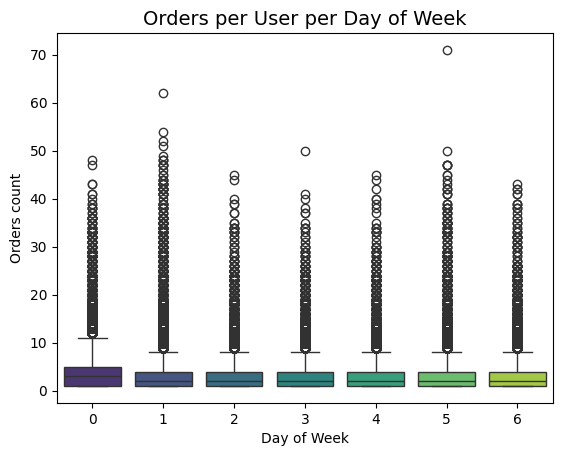

In [63]:
df = pd.DataFrame(res)

# Treat dow as category for consistent coloring
df["dow"] = df["dow"].astype("category")

# Pick a nice palette
palette = sns.color_palette("viridis", len(df["dow"].unique()))

sns.boxplot(
    data=df,
    x="dow",
    y="count",
    hue="dow",         
    palette=palette,
    legend=False        
)

plt.title("Orders per User per Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Orders count")
plt.show()



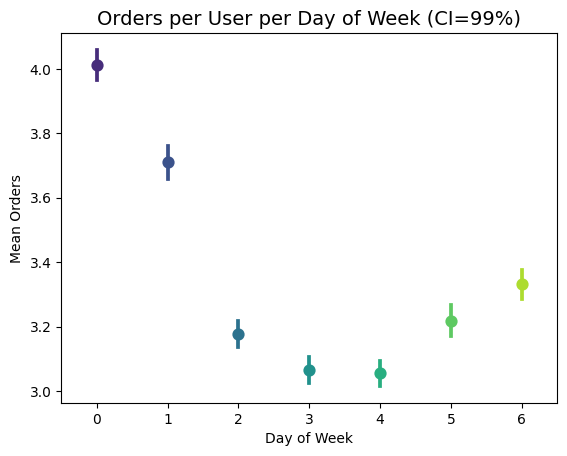

In [64]:
# Another representation: pointplot with confidence intervals


sns.pointplot(
    data=df,
    x="dow",
    y="count",
    hue="dow",                 
    palette=palette,           
    errorbar=('ci', 99),       
    linestyle='none',          
    legend=False             
)

plt.title("Orders per User per Day of Week (CI=99%)", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Mean Orders")
plt.show()


1.5 Weekend Rush vs. Weekday Routine: When Do People Order?

In [65]:

cursor = cll.find(
    {},
    {'_id': 0, 'order_dow': 1, 'order_hour_of_day': 1}
)

# Load the data into a pandas DataFrame
df_orders = pd.DataFrame(list(cursor))


In [66]:
df_orders

,order_dow,order_hour_of_day
0,2,8
1,3,7
2,3,12
3,4,7
4,4,15
...,...,...
999995,2,16
999996,3,10
999997,1,14
999998,4,16


In [67]:
# Define a function to classify the day of the week
def get_day_type(dow):
    if dow in [0, 6]:
        return 'Weekend'
    else:
        return 'Weekday'

# Apply this function to the 'order_dow' column to create our new 'day_type' column
df_orders['day_type'] = df_orders['order_dow'].apply(get_day_type)



In [68]:
df_orders

,order_dow,order_hour_of_day,day_type
0,2,8,Weekday
1,3,7,Weekday
2,3,12,Weekday
3,4,7,Weekday
4,4,15,Weekday
...,...,...,...
999995,2,16,Weekday
999996,3,10,Weekday
999997,1,14,Weekday
999998,4,16,Weekday


In [70]:
# ---- Count how many unique days exist in each category ----
day_counts = df_orders.groupby('day_type')['order_dow'].nunique()

# ---- Group by hour & day_type ----
hourly = (
    df_orders.groupby(['day_type', 'order_hour_of_day'])
             .size()
             .reset_index(name='count')
)

# ---- Convert raw count to average per day ----
hourly['avg_per_day'] = hourly.apply(
    lambda row: row['count'] / day_counts[row['day_type']],
    axis=1
)




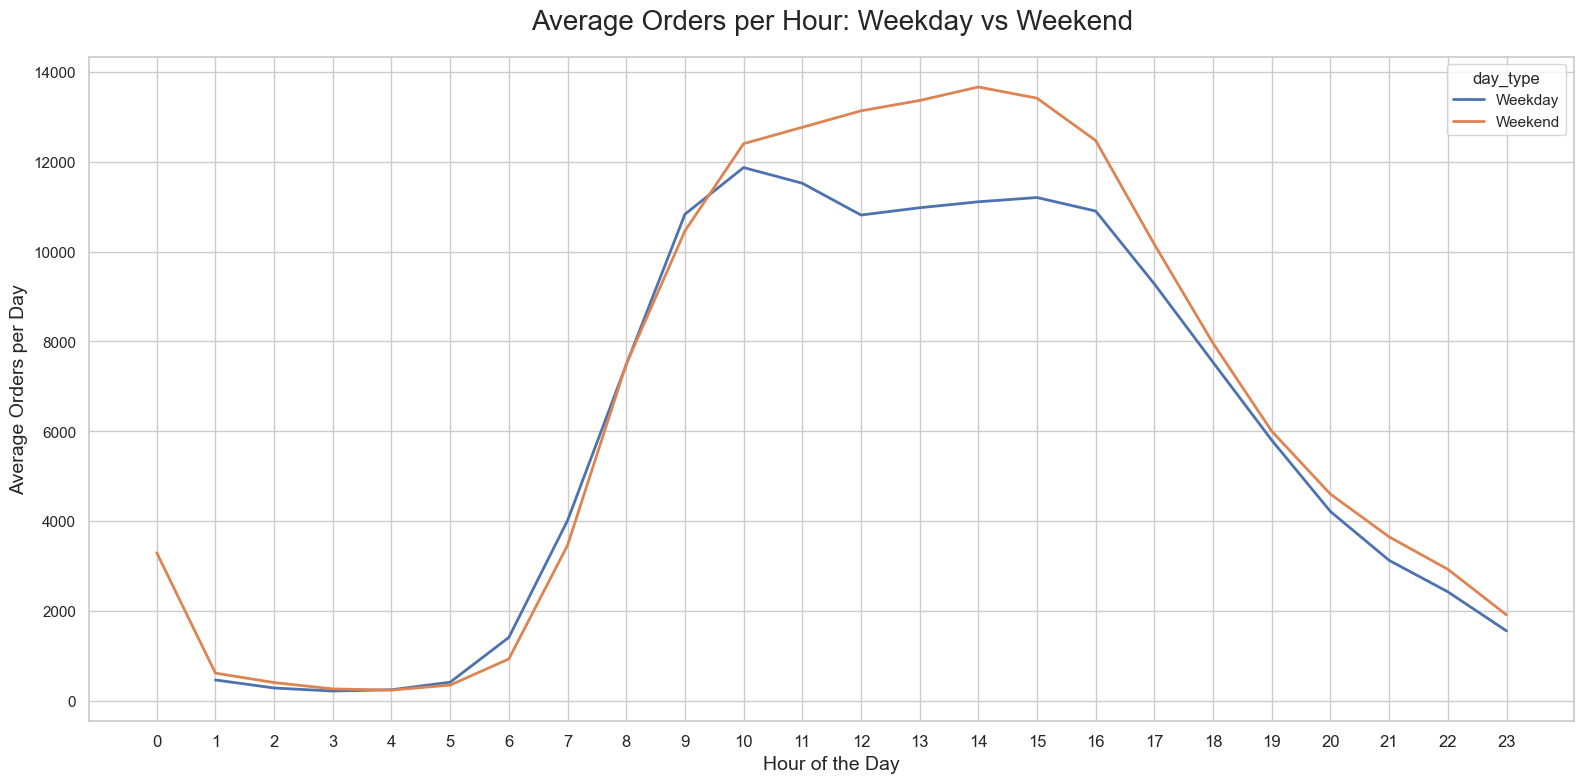

In [71]:
# ---- Plot ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=hourly,
    x='order_hour_of_day',
    y='avg_per_day',
    hue='day_type',
    linewidth=2
)

plt.title('Average Orders per Hour: Weekday vs Weekend', fontsize=20, pad=20)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Average Orders per Day', fontsize=14)

# Show every hour label on x-axis
plt.xticks(range(0, 24), fontsize=12)

plt.tight_layout()
plt.show()

In [72]:
cursor = cll.find(
    {
        "order_hour_of_day": 0,
        "order_dow": {"$nin": [0, 6]}
    },
    {
        "_id": 0,
        "order_dow": 1,
        "order_hour_of_day": 1
    }
)
df_midnight_weekdays = pd.DataFrame(list(cursor))

1.6 Total orders for "Soda" per day

In [74]:

cursor = cll.find(
    {},
    {'_id': 0, 'order_dow': 1, 'products.product_name': 1}
)

# Initialize a dictionary to hold our counts for each day (0-6)
soda_orders_by_day = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}

# Loop through every document returned by our query
for order in cursor:
    day_of_week = order.get('order_dow')
    
    #  Get the 'products' array ---
    products = order.get('products', [])


    if day_of_week is None:
        continue


    contains_soda = False
    for product in products:
        # Check if 'soda' is IN the product name (case-insensitive) ---
        product_name = product.get('product_name', '').lower()
        if 'soda' in product_name:
            contains_soda = True
            break 


    if contains_soda:
        soda_orders_by_day[day_of_week] += 1

# convert our dictionary of counts into a DataFrame for plotting
df_soda_counts = pd.DataFrame(
    list(soda_orders_by_day.items()),
    columns=['day_of_week', 'soda_order_count']
)



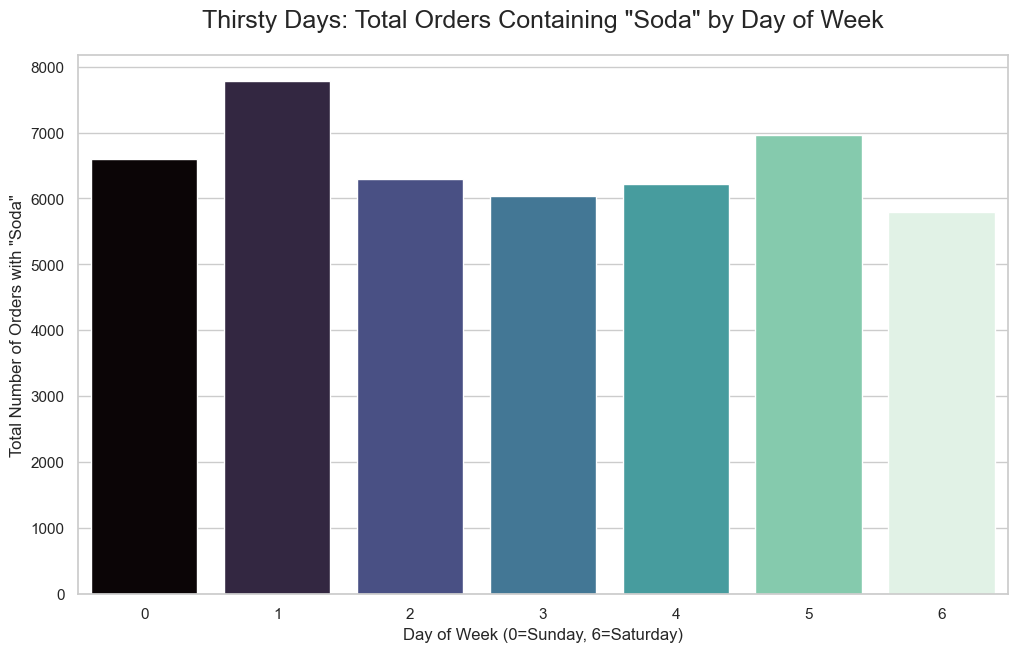

In [75]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


sns.barplot(
    data=df_soda_counts,
    x='day_of_week',
    y='soda_order_count',
    hue='day_of_week', 
    palette='mako',
    legend=False       
)


plt.title('Thirsty Days: Total Orders Containing "Soda" by Day of Week', fontsize=18, pad=20)
plt.xlabel('Day of Week (0=Sunday, 6=Saturday)', fontsize=12)
plt.ylabel('Total Number of Orders with "Soda"', fontsize=12)

plt.show()




# 4. Asynchronous queries with Motor

In [ ]:
#!pip install motor

In [76]:
import asyncio
import nest_asyncio # For nested asynchorous operations, necessary in Jupyter but often unnecessary in Python scripts
from motor.motor_asyncio import AsyncIOMotorClient
from time import sleep

nest_asyncio.apply()

async def ping_server():
    # Replace the placeholder with your Atlas connection string
    uri = "mongodb://localhost:27017/"
    
    # Set the Stable API version when creating a new client
    client = AsyncIOMotorClient(uri)
    
    # Send a ping to confirm a successful connection
    try:
        await client.admin.command('ping')
        print("Pinged your deployment. You successfully connected to MongoDB!")
    except Exception as e:
        print(e)

    return client

ping_server()

<coroutine object ping_server at 0x00000230362EB920>

In [77]:
client = asyncio.run(ping_server())

Pinged your deployment. You successfully connected to MongoDB!


In [78]:
type(client)

motor.motor_asyncio.AsyncIOMotorClient

In [79]:
future = client.list_database_names()
type(future)

asyncio.futures.Future

In [80]:
future.result()

['FaithInterFolia', 'admin', 'config', 'instacart', 'local']

In [81]:
asyncio.run(client.list_database_names())

['FaithInterFolia', 'admin', 'config', 'instacart', 'local']

In [82]:
db = client['instacart']
cll = db['orders']
cll

AsyncIOMotorCollection(Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=False, driver=DriverInfo(name='Motor', version='3.7.1', platform='asyncio')), 'instacart'), 'orders'))

In [83]:
group = {"$group": {"_id":{"user_id":"$user_id", "dow":"$order_dow"}, "count": {"$sum": 1}}}
project = {"$project":{"user_id":"$_id.user_id", "dow":"$_id.dow", "count":1, "_id":0}}

asyncio.run(cll.aggregate([group, project]).to_list())

[{'count': 11, 'user_id': 12860, 'dow': 0},
 {'count': 2, 'user_id': 31426, 'dow': 5},
 {'count': 2, 'user_id': 34217, 'dow': 5},
 {'count': 6, 'user_id': 38462, 'dow': 5},
 {'count': 1, 'user_id': 50678, 'dow': 5},
 {'count': 1, 'user_id': 52068, 'dow': 3},
 {'count': 2, 'user_id': 57824, 'dow': 3},
 {'count': 2, 'user_id': 13501, 'dow': 3},
 {'count': 4, 'user_id': 34172, 'dow': 4},
 {'count': 1, 'user_id': 27275, 'dow': 1},
 {'count': 1, 'user_id': 40478, 'dow': 2},
 {'count': 2, 'user_id': 41390, 'dow': 0},
 {'count': 1, 'user_id': 55399, 'dow': 0},
 {'count': 1, 'user_id': 54850, 'dow': 4},
 {'count': 1, 'user_id': 38911, 'dow': 4},
 {'count': 2, 'user_id': 41609, 'dow': 2},
 {'count': 1, 'user_id': 6063, 'dow': 3},
 {'count': 1, 'user_id': 27643, 'dow': 0},
 {'count': 1, 'user_id': 18623, 'dow': 3},
 {'count': 2, 'user_id': 1040, 'dow': 3},
 {'count': 1, 'user_id': 19812, 'dow': 4},
 {'count': 1, 'user_id': 29249, 'dow': 5},
 {'count': 4, 'user_id': 50801, 'dow': 0},
 {'count': 1

Note: (if you want to do fix for the Sunday)

In [84]:
# 1. Define the filter to find all the "broken" documents
filter_criteria = {"$or": [{"order_dow": None},{"order_hour_of_day": None}]}

# 2. Define the change you want to make
update_action = {"$set": {"order_dow": 0,"order_hour_of_day": 0}}

# 3. Execute the update command
# This will find every document matching the filter and apply the update to it.
result = cll.update_many(filter_criteria, update_action)

# 4. Print how many documents were fixed
print(f"Successfully updated {result.modified_count} documents.")

AttributeError: 'Future' object has no attribute 'modified_count'